Importation des bibliothèques

In [25]:
import os
import random
import torch
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import copy
import numpy as np
import pandas as pd 
import config

In [26]:
from models import SimpleCNN, CNN_MCdropout
from dataset import load_resnet18
from train import train_model, evaluate
from utils import mc_predict_mean_probs, generate_mc_outputs
from accuracy import accuracy_threshold, monotonic_rearrangement, isotonic_regression, monotonicity_penalty
from Resnet import resnet18

In [27]:
print(os.getcwd())  # donne le répertoire courant

d:\INRIA\MCDropout


Fixation du seed pour la reproductibilité

In [28]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Configuration de base

Importation du modèle déjà entraîné par l'utilisateur

In [29]:
trainloader, valloader, testloader, classes = load_resnet18(batch_size=32, val_ratio=0.1)

Test manuel de plusieurs dico_layers et stockage des résultats

In [ ]:
dico_layers_1 = {
    "layer1": 0.1,
    "layer2": 0.1,
    "layer3": 0.1,
    "layer4": 0.1,
    "fc": 0.1,
}
dico_layers_2 = {
    "layer1": 0.1,
    "layer2": 0.1,
    "layer3": 0.1,
    "layer4": 0.1,
    "fc": 0.1,
}
dico_layers_3 = {"fc": 0.7}

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_path = "best_resnet.pt"

# Utilisation du modèle ResNet18 standard (non adapté, non modifié)
base_model = resnet18.to(device)

# # évaluation sans entraînement supplémentaire
# test_loss, test_acc = evaluate(base_model, testloader, device)
# print(f"Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.4f}")

# pour entraîner : sur toutes les couches (ImageNet, 1000 classes)
# base_model = train_model(base_model, trainloader, valloader, device, epochs=20, save_path=save_path)
# base_model.load_state_dict(torch.load(save_path, map_location=device))

base_model_mc1 = copy.deepcopy(base_model)
# base_model_mc2 = copy.deepcopy(base_model)
# base_model_mc3 = copy.deepcopy(base_model)

model_1 = CNN_MCdropout(base_model_mc1, dico_layers=dico_layers_1, before=True).to(device)
# model_2 = CNN_MCdropout(base_model_mc2, dico_layers=dico_layers_2, before=False).to(device)
# model_3 = CNN_MCdropout(base_model_mc3, dico_layers=dico_layers_3, before=True).to(device)

MC Dropout prédiction

je dois garder le même batch ; mettre des seeds pour que ce soit reproductible (fonction de dropout)

In [32]:
results = []

X, Y = next(iter(valloader))
X = torch.nn.functional.interpolate(X, size=(224, 224), mode='bilinear', align_corners=False)
X, Y = X.to(device), Y.to(device)

probs1, t1 = mc_predict_mean_probs(model_1, X, T=15, verbose=True)
Y_hat1 = probs1.argmax(1)
acc1 = (Y_hat1 == Y).float().mean().item()

# probs2, t2 = mc_predict_mean_probs(model_2, X, T=15, verbose=True)
# Y_hat2 = probs2.argmax(1)
# acc2 = (Y_hat2 == Y).float().mean().item()

# probs3, t3 = mc_predict_mean_probs(model_3, X, T=15, verbose=True)
# Y_hat3 = probs3.argmax(1)
# acc3 = (Y_hat3 == Y).float().mean().item()

results.append({
    "model": "model_1",
    "Y_hat": Y_hat1.cpu().numpy(),
    "Y": Y.cpu().numpy(),
    "acc": acc1
})
# results.append({
#     "model": "model_2",
#     "Y_hat": Y_hat2.cpu().numpy(),
#     "Y": Y.cpu().numpy(),
#     "acc": acc2
# })
# results.append({
#     "model": "model_3",
#     "Y_hat": Y_hat3.cpu().numpy(),
#     "Y": Y.cpu().numpy(),
#     "acc": acc3
# })

# Affichage de l'accuracy de chaque modèle
for res in results:
    print(f"Modèle: {res['model']}, Accuracy: {res['acc']:.4f}")

100%|██████████| 15/15 [01:44<00:00,  6.99s/it]

Temps total: 104.83 s  |  Temps moyen par passe: 6.9885 s
Modèle: model_1, Accuracy: 0.1250


Métriques

In [33]:
results_metrics = []

models = [
    ("model_1", model_1),
#     ("model_2", model_2),
#     ("model_3", model_3)
]

# Oui, le valloader ici est basé sur CIFAR-10 car il provient de la fonction load_resnet18 qui prépare les loaders pour ce dataset.
# Si tu veux utiliser ResNet18 pré-entraîné sur ImageNet avec des images adaptées, il faudrait charger un DataLoader avec des images au format ImageNet (224x224, 3 canaux).
# Exemple pour remplacer par un batch d'images ImageNet-like (si tu as un dossier d'images) :

# from torchvision.datasets import ImageFolder
# imagenet_transform = transforms.Compose([
#     transforms.Resize(256),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
# ])
# imagenet_valset = ImageFolder('chemin/vers/val', transform=imagenet_transform)
# imagenet_valloader = DataLoader(imagenet_valset, batch_size=128, shuffle=False)
# X, Y = next(iter(imagenet_valloader))
# X, Y = X.to(device), Y.to(device)

# Sinon, pour rester cohérent avec le modèle pré-entraîné sur ImageNet, il faut au moins redimensionner les images CIFAR-10 à 224x224 :

user_metrics = input(
    "Quelles métriques voulez-vous calculer ?\n"
    "Options disponibles : mc_estimate, variance_predicted, variance_max, predictive_entropy_predicted, predictive_entropy_max, relative_norm\n"
    "Vous pouvez en choisir plusieurs, séparées par des virgules : ")
user_metrics = [m.strip() for m in user_metrics.split(",")]

print_metrics = True  # <-- Ajoutez ce booléen ici

for name, model in models:
    outputs, mean_probs, metric_values, elapsed_forward, elapsed_metrics = generate_mc_outputs(
        model, X, T=15, metrics=user_metrics, labels=Y, verbose=False
    )
    metrics_entry = {
        "model": name,
        "metric_values": metric_values
    }
    results_metrics.append(metrics_entry)
    
    if print_metrics:
        print(f"\nModèle : {name}")
        print(f"Temps total des forward passes : {elapsed_forward:.2f} s\n")
        for metric in user_metrics:
            metric_result = metric_values[metric]
            for r in results:
                if r["model"] == name:
                    if "metrics" not in r:
                        r["metrics"] = {}
                    r["metrics"][metric] = metric_result
                    break

            print(f"--- Métrique choisie : {metric} ---")
            print(f"Temps de calcul : {elapsed_metrics[metric]:.6f} s")
            if metric == "mc_estimate":
                print(f"Distribution de probabilités moyennes (par échantillon) :\n{metric_result}\n")
            elif metric == "variance_max":
                print(f"Variance moyenne (logits) : {metric_values['variance_max_mean']:.6f}")
                print(f"Variance par échantillon :\n{metric_result}\n")
            elif metric == "variance_predicted":
                print(f"Variance softmax moyenne : {metric_values['variance_predicted_mean']:.6f}")
                print(f"Variance softmax par échantillon :\n{metric_result}\n")
            elif metric == "predictive_entropy_max":
                print(f"Entropie prédictive moyenne : {metric_values['predictive_entropy_max_mean']:.6f}")
                print(f"Entropie prédictive par échantillon :\n{metric_result}\n")
            elif metric == "predictive_entropy_predicted":
                print(f"Entropie attendue moyenne : {metric_values['predictive_entropy_predicted_mean']:.6f}")
                print(f"Entropie attendue par échantillon :\n{metric_result}\n")
            elif metric == "relative_norm":
                print(f"Norme relative moyenne : {metric_values['relative_norm_mean']:.6f}")
                print(f"Norme relative par échantillon :\n{metric_result}\n")
            else:
                print(f"Résultat brut :\n{metric_result}\n")
    else:
        # Toujours mettre à jour results même si on n'affiche pas
        for metric in user_metrics:
            metric_result = metric_values[metric]
            for r in results:
                if r["model"] == name:
                    if "metrics" not in r:
                        r["metrics"] = {}
                    r["metrics"][metric] = metric_result
                    break


Modèle : model_1
Temps total des forward passes : 126.62 s

--- Métrique choisie : variance_predicted ---
Temps de calcul : 0.016087 s
Variance softmax moyenne : 0.001173
Variance softmax par échantillon :
tensor([0.0014, 0.0020, 0.0022, 0.0016, 0.0009, 0.0009, 0.0008, 0.0012, 0.0005,
        0.0012, 0.0015, 0.0015, 0.0009, 0.0020, 0.0009, 0.0008, 0.0018, 0.0011,
        0.0010, 0.0011, 0.0006, 0.0014, 0.0013, 0.0010, 0.0006, 0.0011, 0.0013,
        0.0014, 0.0010, 0.0007, 0.0007, 0.0012])

--- Métrique choisie : variance_max ---
Temps de calcul : 0.000000 s
Variance moyenne (logits) : 0.001032
Variance par échantillon :
tensor([0.0014, 0.0020, 0.0016, 0.0015, 0.0009, 0.0009, 0.0003, 0.0012, 0.0004,
        0.0006, 0.0015, 0.0007, 0.0010, 0.0020, 0.0009, 0.0003, 0.0014, 0.0011,
        0.0008, 0.0008, 0.0006, 0.0011, 0.0009, 0.0009, 0.0012, 0.0010, 0.0012,
        0.0014, 0.0010, 0.0007, 0.0005, 0.0012])

--- Métrique choisie : predictive_entropy_predicted ---
Temps de calcul : 0.0178

Fonctions d'accuracy

Seuil de variance_predicted

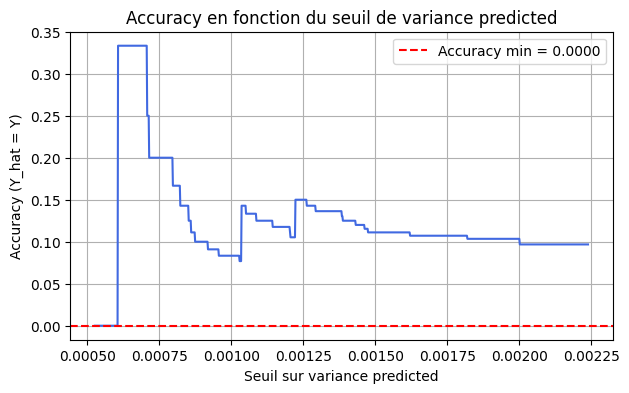

In [34]:
accuracy_results_vp = []

for res in results:
    thresholds_vp, accuracies_vp = accuracy_threshold(
        res["Y_hat"], res["Y"], res["metrics"]["variance_predicted"],
        metric_name="variance predicted", color="royalblue", display=True
    )
    accuracy_results_vp.append({
        "model": res["model"],
        "thresholds_vp": thresholds_vp,
        "accuracies_vp": accuracies_vp
    })

In [35]:
iso_accuracies_results_vp = []

for acc_res in accuracy_results_vp:
    iso_accuracies_vp = isotonic_regression(
        acc_res["thresholds_vp"], acc_res["accuracies_vp"], color='royalblue', display=False
    )
    iso_accuracies_results_vp.append({
        "model": acc_res["model"],
        "iso_accuracies_vp": iso_accuracies_vp
    })

In [36]:
rearranged_accuracies_results_vp = []

for acc_res in accuracy_results_vp:
    rearranged_accuracies_vp = monotonic_rearrangement(
        acc_res["accuracies_vp"], acc_res["thresholds_vp"], acc_res["accuracies_vp"], color='royalblue', display=False
    )
    rearranged_accuracies_results_vp.append({
        "model": acc_res["model"],
        "rearranged_accuracies_vp": rearranged_accuracies_vp
    })

In [37]:
penalties_vp = []

for acc_res, iso_res, rearr_res in zip(accuracy_results_vp, iso_accuracies_results_vp, rearranged_accuracies_results_vp):
    penalty_iso = monotonicity_penalty(acc_res["thresholds_vp"], acc_res["accuracies_vp"], iso_res["iso_accuracies_vp"])
    penalty_rearr = monotonicity_penalty(acc_res["thresholds_vp"], acc_res["accuracies_vp"], rearr_res["rearranged_accuracies_vp"])
    penalties_vp.append({
        "model": acc_res["model"],
        "penalty_isotone": penalty_iso,
        "penalty_rearrangement": penalty_rearr
    })
    print(f"{acc_res['model']} - Pénalité (isotone): {penalty_iso:.6f}, (réarrangement): {penalty_rearr:.6f}")

model_1 - Pénalité (isotone): 0.000041, (réarrangement): 0.000214


Seuil de variance_max

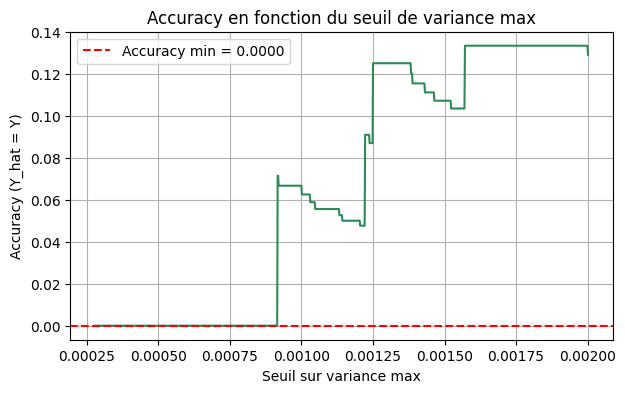

In [38]:
accuracy_results_vm = []

for res in results:
    thresholds_vm, accuracies_vm = accuracy_threshold(
        res["Y_hat"], res["Y"], res["metrics"]["variance_max"],
        metric_name="variance max", color="seagreen", display=True
    )
    accuracy_results_vm.append({
        "model": res["model"],
        "thresholds_vm": thresholds_vm,
        "accuracies_vm": accuracies_vm
    })

In [39]:
iso_accuracies_results_vm = []

for acc_res in accuracy_results_vm:
    iso_accuracies_vm = isotonic_regression(
        acc_res["thresholds_vm"], acc_res["accuracies_vm"], color='seagreen', display=False
    )
    iso_accuracies_results_vm.append({
        "model": acc_res["model"],
        "iso_accuracies_vm": iso_accuracies_vm
    })

In [40]:
rearranged_accuracies_results_vm = []

for acc_res in accuracy_results_vm:
    rearranged_accuracies_vm = monotonic_rearrangement(
        acc_res["accuracies_vm"], acc_res["thresholds_vm"], acc_res["accuracies_vm"], color='seagreen', display=False
    )
    rearranged_accuracies_results_vm.append({
        "model": acc_res["model"],
        "rearranged_accuracies_vm": rearranged_accuracies_vm
    })

In [41]:
penalties_vm = []

for acc_res, iso_res, rearr_res in zip(accuracy_results_vm, iso_accuracies_results_vm, rearranged_accuracies_results_vm):
    penalty_iso = monotonicity_penalty(acc_res["thresholds_vm"], acc_res["accuracies_vm"], iso_res["iso_accuracies_vm"])
    penalty_rearr = monotonicity_penalty(acc_res["thresholds_vm"], acc_res["accuracies_vm"], rearr_res["rearranged_accuracies_vm"])
    penalties_vm.append({
        "model": acc_res["model"],
        "penalty_isotone": penalty_iso,
        "penalty_rearrangement": penalty_rearr
    })
    print(f"{acc_res['model']} - Pénalité (isotone): {penalty_iso:.6f}, (réarrangement): {penalty_rearr:.6f}")

model_1 - Pénalité (isotone): 0.000090, (réarrangement): 0.000115


Seuil de PE_predicted

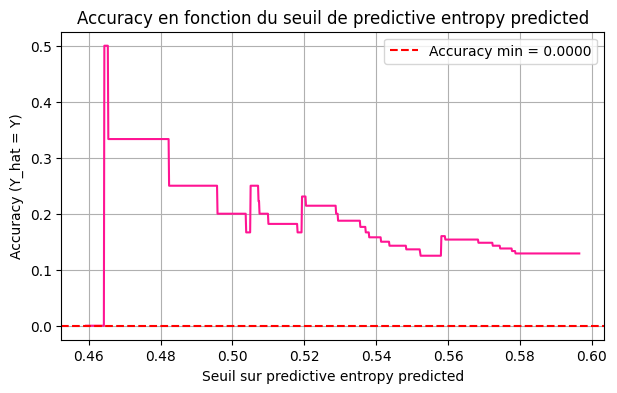

In [42]:
accuracy_results_pep = []

for res in results:
    thresholds_pep, accuracies_pep = accuracy_threshold(
        res["Y_hat"], res["Y"], res["metrics"]["predictive_entropy_predicted"],
        metric_name="predictive entropy predicted", color="deeppink", display=True
    )
    accuracy_results_pep.append({
        "model": res["model"],
        "thresholds_pep": thresholds_pep,
        "accuracies_pep": accuracies_pep
    })

In [43]:
iso_accuracies_results_pep = []

for acc_res in accuracy_results_pep:
    iso_accuracies_pep = isotonic_regression(
        acc_res["thresholds_pep"], acc_res["accuracies_pep"], color='deeppink', display=False
    )
    iso_accuracies_results_pep.append({
        "model": acc_res["model"],
        "iso_accuracies_pep": iso_accuracies_pep
    })

In [44]:
rearranged_accuracies_results_pep = []

for acc_res in accuracy_results_pep:
    rearranged_accuracies_pep = monotonic_rearrangement(
        acc_res["accuracies_pep"], acc_res["thresholds_pep"], acc_res["accuracies_pep"], color='deeppink', display=False
    )
    rearranged_accuracies_results_pep.append({
        "model": acc_res["model"],
        "rearranged_accuracies_pep": rearranged_accuracies_pep
    })

In [45]:
penalties_pep = []

for acc_res, iso_res, rearr_res in zip(accuracy_results_pep, iso_accuracies_results_pep, rearranged_accuracies_results_pep):
    penalty_iso = monotonicity_penalty(acc_res["thresholds_pep"], acc_res["accuracies_pep"], iso_res["iso_accuracies_pep"])
    penalty_rearr = monotonicity_penalty(acc_res["thresholds_pep"], acc_res["accuracies_pep"], rearr_res["rearranged_accuracies_pep"])
    penalties_pep.append({
        "model": acc_res["model"],
        "penalty_isotone": penalty_iso,
        "penalty_rearrangement": penalty_rearr
    })
    print(f"{acc_res['model']} - Pénalité (isotone): {penalty_iso:.6f}, (réarrangement): {penalty_rearr:.6f}")

model_1 - Pénalité (isotone): 0.003523, (réarrangement): 0.026066


Seuil de PE_max

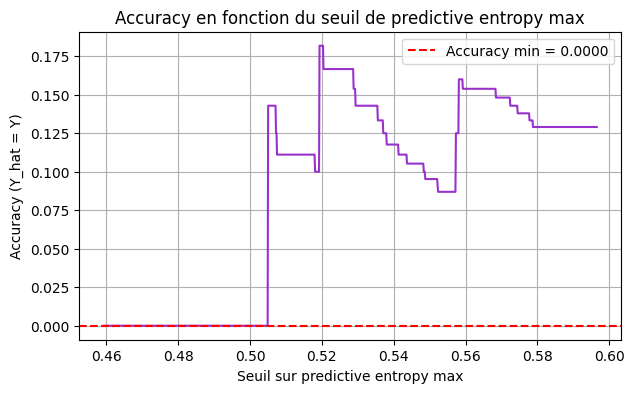

In [46]:
accuracy_results_pem = []

for res in results:
    thresholds_pem, accuracies_pem = accuracy_threshold(
        res["Y_hat"], res["Y"], res["metrics"]["predictive_entropy_max"],
        metric_name="predictive entropy max", color="darkorchid", display=True
    )
    accuracy_results_pem.append({
        "model": res["model"],
        "thresholds_pem": thresholds_pem,
        "accuracies_pem": accuracies_pem
    })

In [47]:
iso_accuracies_results_pem = []

for acc_res in accuracy_results_pem:
    iso_accuracies_pem = isotonic_regression(
        acc_res["thresholds_pem"], acc_res["accuracies_pem"], color='darkorchid', display=False
    )
    iso_accuracies_results_pem.append({
        "model": acc_res["model"],
        "iso_accuracies_pem": iso_accuracies_pem
    })

In [48]:
rearranged_accuracies_results_pem = []

for acc_res in accuracy_results_pem:
    rearranged_accuracies_pem = monotonic_rearrangement(
        acc_res["accuracies_pem"], acc_res["thresholds_pem"], acc_res["accuracies_pem"], color='darkorchid', display=False
    )
    rearranged_accuracies_results_pem.append({
        "model": acc_res["model"],
        "rearranged_accuracies_pem": rearranged_accuracies_pem
    })

In [49]:
penalties_pem = []

for acc_res, iso_res, rearr_res in zip(accuracy_results_pem, iso_accuracies_results_pem, rearranged_accuracies_results_pem):
    penalty_iso = monotonicity_penalty(acc_res["thresholds_pem"], acc_res["accuracies_pem"], iso_res["iso_accuracies_pem"])
    penalty_rearr = monotonicity_penalty(acc_res["thresholds_pem"], acc_res["accuracies_pem"], rearr_res["rearranged_accuracies_pem"])
    penalties_pem.append({
        "model": acc_res["model"],
        "penalty_isotone": penalty_iso,
        "penalty_rearrangement": penalty_rearr
    })
    print(f"{acc_res['model']} - Pénalité (isotone): {penalty_iso:.6f}, (réarrangement): {penalty_rearr:.6f}")

model_1 - Pénalité (isotone): 0.007969, (réarrangement): 0.011956


Grid search sur dico_layers et stockage des résultats

In [50]:
# Dictionnaires pour chaque type de pénalité
penalties_dict = {
    "variance_predicted": penalties_vp,
    "variance_max": penalties_vm,
    "predictive_entropy_predicted": penalties_pep,
    "predictive_entropy_max": penalties_pem,
}

# 2. Récupérer les métriques moyennes pour chaque modèle
rows = []
for r in results:
    model = r["model"]
    if "metrics" in r:
        for metric, value in r["metrics"].items():
            # On cherche le type de métrique pour trouver la bonne pénalité
            if metric.startswith("variance_predicted"):
                pen_list = penalties_vp
            elif metric.startswith("variance_max"):
                pen_list = penalties_vm
            elif metric.startswith("predictive_entropy_predicted"):
                pen_list = penalties_pep
            elif metric.startswith("predictive_entropy_max"):
                pen_list = penalties_pem
            else:
                pen_list = []

            # On récupère la pénalité pour ce modèle et cette métrique
            penalty_iso = None
            penalty_rearr = None
            for p in pen_list:
                if p["model"] == model:
                    penalty_iso = p["penalty_isotone"]
                    penalty_rearr = p["penalty_rearrangement"]
                    break

            # Si c'est un tensor, on prend la moyenne
            if isinstance(value, torch.Tensor):
                mean_value = value.mean().item()
                rows.append([
                    model,
                    metric + "_mean",
                    penalty_iso,
                    penalty_rearr,
                    mean_value
                ])
            # Si c'est un float/int
            elif isinstance(value, (float, int, np.floating, np.integer)):
                rows.append([
                    model,
                    metric,
                    penalty_iso,
                    penalty_rearr,
                    value
                ])
            # Si c'est un dict avec une clé 'mean'
            elif isinstance(value, dict) and "mean" in value:
                rows.append([
                    model,
                    metric + "_mean",
                    penalty_iso,
                    penalty_rearr,
                    value["mean"]
                ])

# 3. Créer le DataFrame multi-indexé
df = pd.DataFrame(rows, columns=["model", "metric", "penalty_isotone", "penalty_rearrangement", "value"])
if not df.empty:
    df = df.set_index(["model", "metric"])[["value", "penalty_isotone", "penalty_rearrangement"]]
    
    def highlight_min(s):
        is_min = s == s.min()
        return ['background-color: #228B22; font-weight: bold' if v else '' for v in is_min]
    
    # On applique le style par colonne, pour chaque métrique (donc groupby niveau 1)
    styled = df.groupby(level=1).apply(lambda g: g.style.apply(highlight_min))
    display(df.style.apply(lambda x: highlight_min(x), subset=["value"], axis=0)
                .apply(lambda x: highlight_min(x), subset=["penalty_isotone"], axis=0)
                .apply(lambda x: highlight_min(x), subset=["penalty_rearrangement"], axis=0))
else:
    print("Aucune donnée à afficher (vérifie la structure de results et metrics).")